In [7]:
# Standard library
import os
import random
import time
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

# Torchvision
import torchvision
import torchvision.transforms as transforms

# Progress bars
from tqdm import tqdm

# Experiment tracking
import wandb


plt.style.use("default")

In [3]:


# 1. Clone your clean repository code from GitHub
REPO_URL = "https://github.com/K0NSTANT1N3/Facial-Expression-Recognition.git"
REPO_NAME = "Facial-Expression-Recognition"

if not os.path.exists(REPO_NAME):
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL}")
else:
    print("Repository already exists. Pulling latest updates...")
    os.system(f"cd {REPO_NAME} && git pull")

# 2. THE SECRET SAUCE: Add your cloned repo directory to Python's path
sys.path.append(os.path.abspath(REPO_NAME))

print("Successfully linked GitHub repository and adjusted system paths!")

Cloning repository...


Cloning into 'Facial-Expression-Recognition'...


Successfully linked GitHub repository and adjusted system paths!


In [10]:
for root, dirs, files in os.walk("/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/fer2013.tar.gz
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/example_submission.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv


In [11]:
df = pd.read_csv("/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv")
df.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [12]:
print("Shape:", df.shape)

df.info()

Shape: (28709, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28709 entries, 0 to 28708
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  28709 non-null  int64 
 1   pixels   28709 non-null  object
dtypes: int64(1), object(1)
memory usage: 448.7+ KB


In [13]:
df.isnull().sum()

emotion    0
pixels     0
dtype: int64

In [14]:
df["emotion"].value_counts().sort_index()

emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64

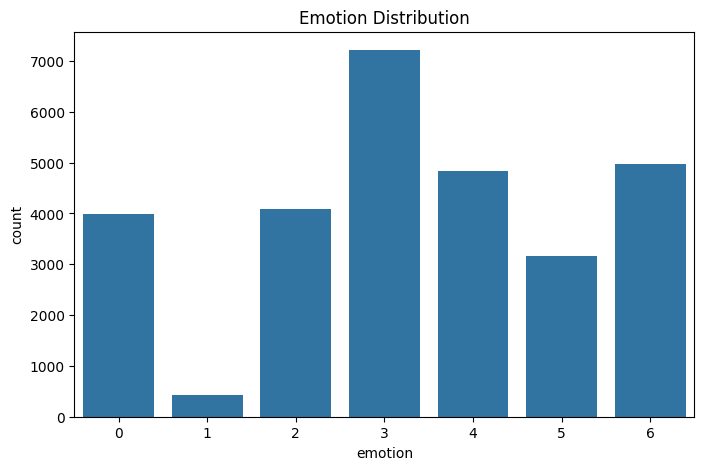

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="emotion"
)

plt.title("Emotion Distribution")
plt.show()

In [16]:
def pixels_to_image(pixel_string):
    pixels = np.array(pixel_string.split(), dtype=np.uint8)
    return pixels.reshape(48, 48)

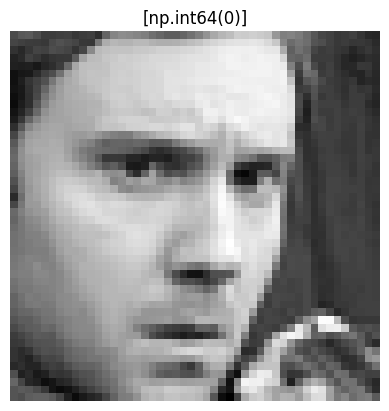

In [20]:
sample = pixels_to_image(df.iloc[0]["pixels"])

plt.imshow(sample, cmap="gray")
plt.title([df.iloc[0]["emotion"]])
plt.axis("off")
plt.show()



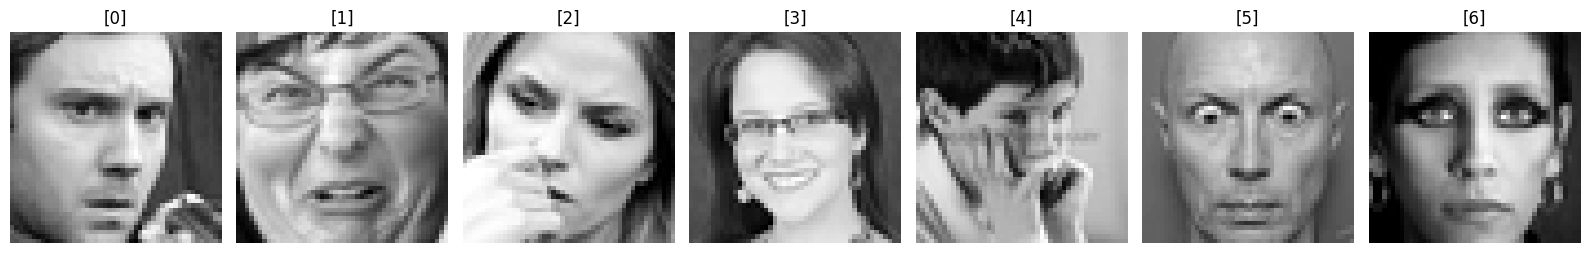

In [22]:
fig, axes = plt.subplots(1, 7, figsize=(16,4))

for emotion in range(7):
    
    sample_row = df[df["emotion"] == emotion].iloc[0]
    
    image = pixels_to_image(sample_row["pixels"])
    
    axes[emotion].imshow(image, cmap="gray")
    axes[emotion].set_title([emotion])
    axes[emotion].axis("off")

plt.tight_layout()
plt.show()

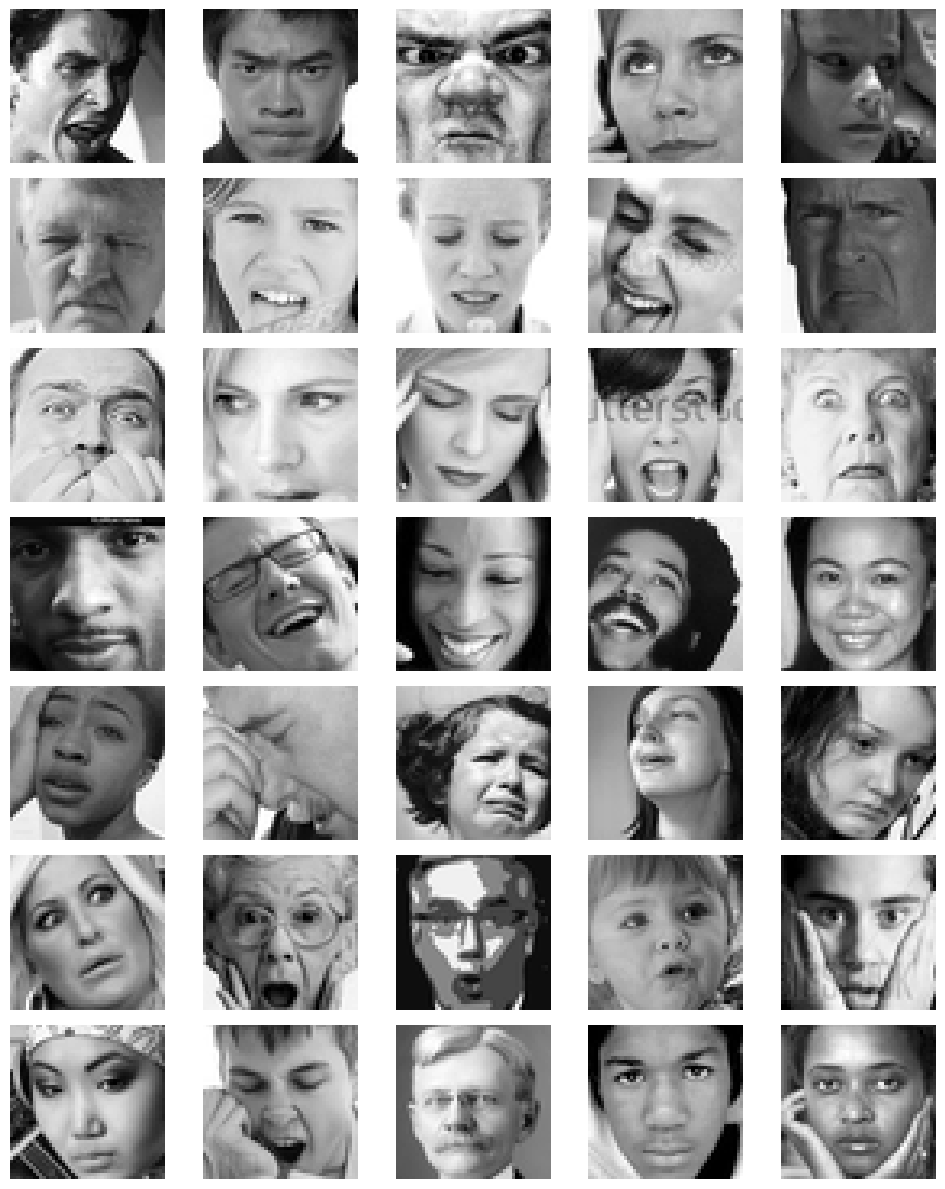

In [24]:
fig, axes = plt.subplots(7, 5, figsize=(10,12))

for emotion in range(7):
    
    samples = df[df["emotion"] == emotion].sample(5, random_state=42)
    
    for j, (_, row) in enumerate(samples.iterrows()):
        
        image = pixels_to_image(row["pixels"])
        
        axes[emotion, j].imshow(image, cmap="gray")
        axes[emotion, j].axis("off")
        
        if j == 0:
            axes[emotion, j].set_ylabel(
                [emotion],
                rotation=0,
                labelpad=40
            )

plt.tight_layout()
plt.show()

In [25]:
all_pixels = []

for pixel_string in df["pixels"]:
    pixels = np.array(pixel_string.split(), dtype=np.uint8)
    all_pixels.extend(pixels)

all_pixels = np.array(all_pixels)

print("Min:", all_pixels.min())
print("Max:", all_pixels.max())
print("Mean:", all_pixels.mean())
print("Std:", all_pixels.std())

Min: 0
Max: 255
Mean: 129.47433955331468
Std: 65.02727348443113


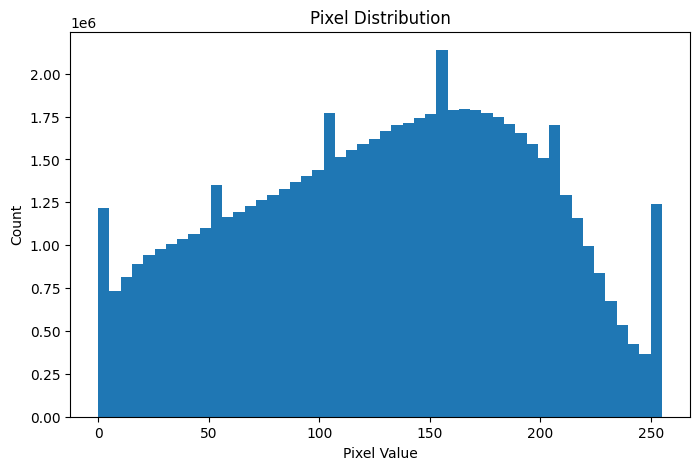

In [26]:
plt.figure(figsize=(8,5))

plt.hist(all_pixels, bins=50)

plt.title("Pixel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Count")

plt.show()